# Breakout Player Identification

Identifies MLB players who are likely to break out in the upcoming season using historical FanGraphs + Statcast data (2015–2024).

## Methodology

**Breakout definition:** A player who jumped ≥2.0 WAR year-over-year *and* sustained that higher level the following season (WAR drop ≤1.0).

**No data leakage:** All features come from Year N-1 (the season before the breakout). Year N and N+1 WAR are used only to assign the label.

**Two ML models per player type (batters and pitchers):**
1. **K-Means clustering** on historical breakout players → reveals archetypes (who breaks out and why)
2. **Decision Tree classifier** on all labeled players → predicts breakout probability from pre-season stats

**Output:** Top 2025 breakout candidates ranked by model probability, with cluster archetype assignment.

## Section 1: Setup & Config

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report

import pybaseball
from pybaseball import (
    batting_stats,
    pitching_stats,
    statcast_batter_exitvelo_barrels,
    statcast_pitcher_pitch_arsenal,
)
pybaseball.cache.enable()

pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 130)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Ready.')

Ready.


In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
SEASONS       = [yr for yr in range(2015, 2025) if yr != 2020]  # exclude shortened COVID season
PRED_SEASON   = 2024                      # apply model to this year to predict 2025
TRAIN_CUTOFF  = 2022                      # feature seasons ≤ this used for training

WAR_JUMP      = 2.0    # minimum WAR increase to qualify as a breakout
WAR_SUSTAIN   = 1.0    # max allowable WAR drop in the confirmation year

MIN_PA_FEAT   = 250    # min PA in feature year (Year N-1)
MIN_PA_BO     = 350    # min PA in breakout year (Year N)
MIN_IP_FEAT   = 40     # min IP in feature year
MIN_IP_BO     = 60     # min IP in breakout year

N_CLUSTERS    = 4      # K-Means clusters
TREE_DEPTH    = 4      # Decision Tree max depth
RANDOM_STATE  = 42

CLUSTER_COLORS = ['#e6194b', '#3cb44b', '#4363d8', '#f58231']

print(f'Seasons: {SEASONS[0]}–{SEASONS[-1]} (excl. 2020)  |  breakout threshold: +{WAR_JUMP} WAR  |  predict: {PRED_SEASON}→{PRED_SEASON+1}')

Seasons: 2015–2024 (excl. 2020)  |  breakout threshold: +2.0 WAR  |  predict: 2024→2025


## Section 2: Data Loading (2015–2024)

Loads FanGraphs leaderboards and Statcast aggregates for every season. Results are cached locally — first run takes ~5 minutes; subsequent runs are instant.

In [3]:
def _build_name(val):
    """Convert 'last, first' Statcast name to 'first last'."""
    if isinstance(val, str) and ',' in val:
        parts = val.split(',', 1)
        return f'{parts[1].strip()} {parts[0].strip()}'
    return str(val) if val else ''


bat_seasons, sc_bat_seasons = [], []

for yr in SEASONS:
    print(f'  Batting {yr}...', end=' ')
    b = batting_stats(yr, qual=0)
    b['Season'] = yr
    bat_seasons.append(b)

    sc = statcast_batter_exitvelo_barrels(yr)
    sc['Season'] = yr
    name_col = 'last_name, first_name' if 'last_name, first_name' in sc.columns else None
    if name_col:
        sc['Name'] = sc[name_col].apply(_build_name)
    keep = ['Name', 'Season', 'avg_hit_speed', 'max_hit_speed', 'brl_pa', 'brl_percent']
    keep = [c for c in keep if c in sc.columns]
    sc_bat_seasons.append(sc[keep])
    print('ok')

raw_bat    = pd.concat(bat_seasons, ignore_index=True)
raw_sc_bat = pd.concat(sc_bat_seasons, ignore_index=True)
bat_all    = raw_bat.merge(raw_sc_bat, on=['Name', 'Season'], how='left')
bat_all['IDfg'] = bat_all['IDfg'].astype(float).astype('Int64').astype(str)

print(f'\nBatting rows: {len(bat_all):,}  seasons: {bat_all["Season"].nunique()}  players: {bat_all["IDfg"].nunique():,}')

  Batting 2015... ok
  Batting 2016... ok
  Batting 2017... ok
  Batting 2018... ok
  Batting 2019... ok
  Batting 2021... ok
  Batting 2022... ok
  Batting 2023... ok
  Batting 2024... 

ok



Batting rows: 12,762  seasons: 9  players: 3,753


In [4]:
pit_seasons, sc_pit_seasons = [], []

for yr in SEASONS:
    print(f'  Pitching {yr}...', end=' ')
    p = pitching_stats(yr, qual=0)
    p['Season'] = yr
    pit_seasons.append(p)

    try:
        sp = statcast_pitcher_pitch_arsenal(yr, minP=100, arsenal_type='avg_spin')
        sp['Season'] = yr
        name_col = 'last_name, first_name' if 'last_name, first_name' in sp.columns else None
        if name_col:
            sp['Name'] = sp[name_col].apply(_build_name)
        spin_cols = [c for c in sp.columns if 'avg_spin' in c.lower()]
        keep = [c for c in ['Name', 'Season'] + spin_cols if c in sp.columns]
        sc_pit_seasons.append(sp[keep])
        print(f'ok ({len(spin_cols)} spin cols)')
    except Exception as e:
        print(f'spin unavailable ({e})')

raw_pit    = pd.concat(pit_seasons, ignore_index=True)
raw_sc_pit = pd.concat(sc_pit_seasons, ignore_index=True) if sc_pit_seasons else pd.DataFrame()

if not raw_sc_pit.empty:
    pit_all = raw_pit.merge(raw_sc_pit, on=['Name', 'Season'], how='left')
else:
    pit_all = raw_pit.copy()

pit_all['IDfg'] = pit_all['IDfg'].astype(float).astype('Int64').astype(str)

# Derive role: SP if GS/G >= 0.5 else RP
pit_all['role'] = pit_all.apply(
    lambda r: 'SP' if (r.get('GS', 0) or 0) / max(r.get('G', 1) or 1, 1) >= 0.5 else 'RP', axis=1
)

print(f'\nPitching rows: {len(pit_all):,}  seasons: {pit_all["Season"].nunique()}  players: {pit_all["IDfg"].nunique():,}')

  Pitching 2015... ok (10 spin cols)
  Pitching 2016... ok (10 spin cols)
  Pitching 2017... ok (10 spin cols)
  Pitching 2018... ok (10 spin cols)
  Pitching 2019... ok (10 spin cols)
  Pitching 2021... ok (10 spin cols)
  Pitching 2022... ok (10 spin cols)
  Pitching 2023... ok (10 spin cols)
  Pitching 2024... ok (10 spin cols)



Pitching rows: 7,369  seasons: 9  players: 2,405


## Section 3: Breakout Label Construction

For each player, scan their season history and identify triples (N-1, N, N+1) where:
- WAR jumped ≥2.0 from Year N-1 → Year N
- WAR stayed high in Year N+1 (drop ≤1.0)

The feature row is always Year N-1 data. Year N and N+1 are used only for the label.

In [5]:
def build_breakout_labels(df, id_col='IDfg', war_col='WAR',
                          vol_col='PA', min_vol_feat=250, min_vol_bo=350):
    """
    Return one row per (player, feature_season) with a breakout label.
    Features are all from feature_season (Year N-1).
    Label is determined by Year N jump + Year N+1 confirmation.
    """
    df = df.copy()
    df[id_col] = df[id_col].astype(str)

    # Deduplicate: traded players appear multiple times per season (split stats).
    # Keep the row with the highest vol_col (full-season equivalent).
    if vol_col in df.columns:
        df[vol_col] = pd.to_numeric(df[vol_col], errors='coerce').fillna(0)
        df = df.sort_values(vol_col, ascending=False).drop_duplicates(subset=[id_col, 'Season'])
    df = df.sort_values([id_col, 'Season'])

    labeled = []
    for pid, grp in df.groupby(id_col):
        grp = grp.set_index('Season').sort_index()
        seasons = sorted(grp.index.tolist())
        for yr_n in seasons:
            yr_n1     = yr_n - 1
            yr_n_plus = yr_n + 1
            if yr_n1 not in grp.index or yr_n_plus not in grp.index:
                continue

            feat = grp.loc[yr_n1]
            bo   = grp.loc[yr_n]
            conf = grp.loc[yr_n_plus]

            # After dedup, each loc returns a Series (scalar values)
            def _scalar(series, key, default=0):
                val = series[key] if key in series.index else default
                try:
                    return float(val)
                except (TypeError, ValueError):
                    return float(default)

            if _scalar(feat, vol_col) < min_vol_feat:
                continue
            if _scalar(bo, vol_col) < min_vol_bo:
                continue

            war_n1_val = _scalar(feat, war_col)
            war_bo     = _scalar(bo, war_col)
            war_conf   = _scalar(conf, war_col)
            war_jump   = war_bo - war_n1_val

            is_breakout = int(
                war_jump >= WAR_JUMP and
                war_conf >= (war_bo - WAR_SUSTAIN)
            )

            row = feat.copy()
            row['feature_season'] = yr_n1
            row['label_season']   = yr_n
            row['war_n1']         = war_n1_val
            row['war_n']          = war_bo
            row['war_n_plus1']    = war_conf
            row['war_jump']       = war_jump
            row['breakout']       = is_breakout
            row[id_col]           = pid
            labeled.append(row)

    result = pd.DataFrame(labeled).reset_index(drop=True)
    return result


labeled_bat = build_breakout_labels(bat_all, vol_col='PA',
                                    min_vol_feat=MIN_PA_FEAT, min_vol_bo=MIN_PA_BO)
labeled_pit = build_breakout_labels(pit_all, vol_col='IP',
                                    min_vol_feat=MIN_IP_FEAT, min_vol_bo=MIN_IP_BO)

print(f'Batting labeled:  {len(labeled_bat):,} rows  |  breakouts: {labeled_bat["breakout"].sum()}  '
      f'({100*labeled_bat["breakout"].mean():.1f}%)')
print(f'Pitching labeled: {len(labeled_pit):,} rows  |  breakouts: {labeled_pit["breakout"].sum()}  '
      f'({100*labeled_pit["breakout"].mean():.1f}%)')

Batting labeled:  948 rows  |  breakouts: 50  (5.3%)
Pitching labeled: 918 rows  |  breakouts: 30  (3.3%)


In [6]:
def add_trend_features(df, id_col='IDfg', stat_cols=None):
    """Add delta columns (Year N-1 minus Year N-2) computed within each player group."""
    df = df.copy().sort_values([id_col, 'feature_season'])
    stat_cols = [c for c in stat_cols if c in df.columns]
    prev = df.groupby(id_col)[stat_cols].shift(1)
    for col in stat_cols:
        df[f'd_{col}'] = df[col] - prev[col]
    return df


BAT_TREND_COLS = ['K%', 'BB%', 'Hard%', 'avg_hit_speed', 'brl_percent', 'wRC+', 'ISO']
PIT_TREND_COLS = ['K%', 'BB%', 'FIP', 'xFIP', 'GB%']

labeled_bat = add_trend_features(labeled_bat, stat_cols=BAT_TREND_COLS)
labeled_pit = add_trend_features(labeled_pit, stat_cols=PIT_TREND_COLS)

print('Trend features added.')
print('Sample breakout players:')
labeled_bat[labeled_bat['breakout'] == 1][['Name', 'feature_season', 'label_season',
                                            'war_n1', 'war_n', 'war_jump', 'war_n_plus1']].head(10)

Trend features added.
Sample breakout players:


,Name,feature_season,label_season,war_n1,war_n,war_jump,war_n_plus1
0,Chris Owings,2015,2016,-1.10,0.90,2.00,0.60
31,Marcell Ozuna,2022,2023,-0.30,3.20,3.50,4.70
43,Cesar Hernandez,2015,2016,1.30,3.40,2.10,2.80
70,Jonathan Schoop,2015,2016,1.30,3.50,2.20,4.50
74,Whit Merrifield,2016,2017,0.90,3.30,2.40,5.00
107,Bryce Harper,2016,2017,1.90,4.10,2.20,3.20
125,J.T. Realmuto,2015,2016,0.20,2.30,2.10,4.50
126,J.T. Realmuto,2016,2017,2.30,4.50,2.20,4.70
143,Jon Berti,2021,2022,0.20,2.20,2.00,2.20
191,Eugenio Suarez,2021,2022,0.00,4.30,4.30,3.50


## Section 4: Feature Sets

All features are from the **feature year (Year N-1)**. Trend deltas capture momentum: `d_X = X[N-1] - X[N-2]`.

In [7]:
BAT_FEATURES_BASE = [
    # Core production
    'wRC+', 'WAR', 'ISO', 'BABIP',
    # Plate discipline
    'BB%', 'K%', 'SwStr%', 'O-Contact%', 'Z-Contact%',
    # Batted ball profile
    'Hard%', 'GB%', 'FB%', 'HR/FB',
    # Statcast quality of contact
    'avg_hit_speed', 'brl_percent', 'brl_pa',
    # Context
    'Age', 'PA',
]
BAT_TREND_FEAT = [f'd_{c}' for c in BAT_TREND_COLS]
BAT_FEATURES   = BAT_FEATURES_BASE + BAT_TREND_FEAT

PIT_FEATURES_BASE = [
    # Core value
    'WAR', 'FIP', 'xFIP', 'ERA',
    # Stuff / control
    'K%', 'BB%', 'K/9', 'BB/9',
    # Batted ball
    'GB%', 'HR/FB',
    # Context
    'Age', 'IP',
]
PIT_TREND_FEAT = [f'd_{c}' for c in PIT_TREND_COLS]

# Add available spin columns dynamically
spin_cols = [c for c in labeled_pit.columns if 'avg_spin' in c.lower()]
PIT_FEATURES = PIT_FEATURES_BASE + spin_cols + PIT_TREND_FEAT

# Guard: keep only columns that actually exist
BAT_FEATURES = [c for c in BAT_FEATURES if c in labeled_bat.columns]
PIT_FEATURES = [c for c in PIT_FEATURES if c in labeled_pit.columns]

print(f'Batter features ({len(BAT_FEATURES)}):  {BAT_FEATURES}')
print(f'\nPitcher features ({len(PIT_FEATURES)}): {PIT_FEATURES}')

Batter features (25):  ['wRC+', 'WAR', 'ISO', 'BABIP', 'BB%', 'K%', 'SwStr%', 'O-Contact%', 'Z-Contact%', 'Hard%', 'GB%', 'FB%', 'HR/FB', 'avg_hit_speed', 'brl_percent', 'brl_pa', 'Age', 'PA', 'd_K%', 'd_BB%', 'd_Hard%', 'd_avg_hit_speed', 'd_brl_percent', 'd_wRC+', 'd_ISO']

Pitcher features (27): ['WAR', 'FIP', 'xFIP', 'ERA', 'K%', 'BB%', 'K/9', 'BB/9', 'GB%', 'HR/FB', 'Age', 'IP', 'ff_avg_spin', 'si_avg_spin', 'fc_avg_spin', 'sl_avg_spin', 'ch_avg_spin', 'cu_avg_spin', 'fs_avg_spin', 'kn_avg_spin', 'st_avg_spin', 'sv_avg_spin', 'd_K%', 'd_BB%', 'd_FIP', 'd_xFIP', 'd_GB%']


## Section 5: Batter ML

### 5a — K-Means Clustering on Historical Breakout Batters
Clusters the population of batters who *did* break out to reveal archetypes: e.g., contact hitters who added power, power hitters who fixed their K rate, etc.

### 5b — Decision Tree Classifier
Trained on all labeled batters (breakout vs non-breakout) using features from the prior season. Extracts which attributes best separate future breakouts from the field.

In [8]:
# Drop rows where trend features are entirely missing (first season per player)
trend_cols_present = [c for c in BAT_TREND_FEAT if c in labeled_bat.columns]
bat_ml = labeled_bat.dropna(subset=trend_cols_present[:2]).copy()

X_bat = bat_ml[BAT_FEATURES].copy()
y_bat = bat_ml['breakout'].values
bat_feat_names = list(X_bat.columns)  # ground truth feature names for model outputs

print(f'Batter ML matrix: {X_bat.shape}  |  breakouts: {y_bat.sum()} ({100*y_bat.mean():.1f}%)')
print(f'NaN coverage per feature (top 10 most sparse):')
print((X_bat.isna().mean() * 100).sort_values(ascending=False).head(10).round(1).to_string())

Batter ML matrix: (522, 25)  |  breakouts: 23 (4.4%)
NaN coverage per feature (top 10 most sparse):
d_brl_percent     20.10
d_avg_hit_speed   20.10
avg_hit_speed     12.50
brl_pa            12.50
brl_percent       12.50
wRC+               0.00
d_wRC+             0.00
d_Hard%            0.00
d_BB%              0.00
d_K%               0.00


In [9]:
# ── K-Means: cluster only breakout batters ────────────────────────────────────
bat_bo = bat_ml[bat_ml['breakout'] == 1].copy()
X_bo_bat = bat_bo[BAT_FEATURES]

pipe_cluster_bat = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('scaler',  StandardScaler()),
])
X_bo_bat_scaled = pipe_cluster_bat.fit_transform(X_bo_bat)

km_bat = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
bat_bo['cluster'] = km_bat.fit_predict(X_bo_bat_scaled)

# Characterize clusters by key median stats
char_cols = [c for c in ['wRC+', 'WAR', 'ISO', 'BABIP', 'K%', 'BB%', 'Hard%', 'avg_hit_speed',
                          'brl_percent', 'Age', 'war_jump'] if c in bat_bo.columns]
cluster_profile = bat_bo.groupby('cluster')[char_cols].median().round(2)
cluster_profile['n'] = bat_bo['cluster'].value_counts().sort_index()
print('Batter breakout cluster profiles (medians):')
print(cluster_profile.to_string())

Batter breakout cluster profiles (medians):
          wRC+  WAR  ISO  BABIP   K%  BB%  Hard%  avg_hit_speed  brl_percent   Age  war_jump  n
cluster                                                                                        
0       142.00 3.70 0.21   0.32 0.15 0.12   0.38          91.40        12.40 27.00      2.50  3
1        87.50 0.75 0.20   0.27 0.28 0.09   0.34          89.40         8.90 25.50      2.60  8
2       110.00 3.30 0.18   0.28 0.18 0.10   0.32          90.20         7.10 27.00      2.50  7
3        91.00 1.20 0.12   0.32 0.19 0.07   0.29          88.60         4.15 28.00      2.90  5


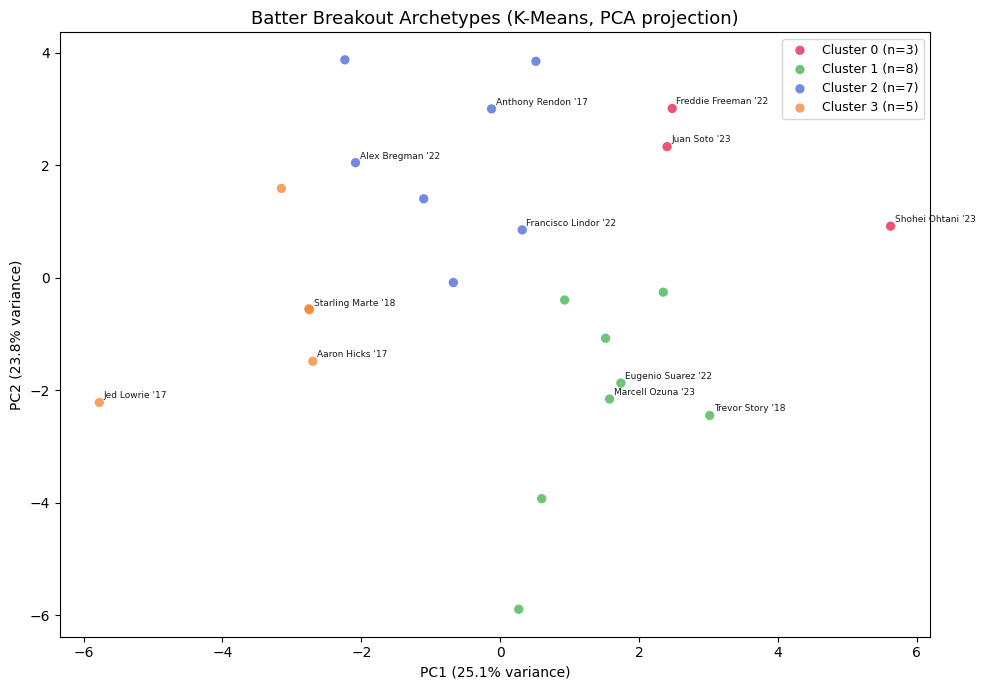

In [10]:
pca_bat = PCA(n_components=2, random_state=RANDOM_STATE)
coords  = pca_bat.fit_transform(X_bo_bat_scaled)
bat_bo['pca1'], bat_bo['pca2'] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(N_CLUSTERS):
    mask = bat_bo['cluster'] == c
    ax.scatter(bat_bo.loc[mask, 'pca1'], bat_bo.loc[mask, 'pca2'],
               c=CLUSTER_COLORS[c], label=f'Cluster {c} (n={mask.sum()})',
               alpha=0.75, s=45, edgecolors='none')
    # Annotate the biggest WAR-jump players in each cluster
    top = bat_bo[mask].nlargest(3, 'war_jump')
    for _, row in top.iterrows():
        ax.annotate(f"{row['Name']} '{str(row['label_season'])[2:]}",
                    (row['pca1'], row['pca2']), fontsize=6.5, alpha=0.9,
                    xytext=(3, 3), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca_bat.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_bat.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Batter Breakout Archetypes (K-Means, PCA projection)', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# ── Decision Tree classifier ──────────────────────────────────────────────────
train_mask = bat_ml['feature_season'] <= TRAIN_CUTOFF
X_train_bat, y_train_bat = X_bat[train_mask], y_bat[train_mask]

pipe_tree_bat = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('scaler',  StandardScaler()),
    ('tree', DecisionTreeClassifier(
        max_depth=TREE_DEPTH,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(pipe_tree_bat, X_train_bat, y_train_bat, cv=cv, scoring='roc_auc')
print(f'Batter tree  CV ROC-AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}')

cv_f1 = cross_val_score(pipe_tree_bat, X_train_bat, y_train_bat, cv=cv, scoring='f1')
print(f'Batter tree  CV F1:      {cv_f1.mean():.3f} ± {cv_f1.std():.3f}')

pipe_tree_bat.fit(X_train_bat, y_train_bat)

Batter tree  CV ROC-AUC: 0.578 ± 0.104


Batter tree  CV F1:      0.125 ± 0.061


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

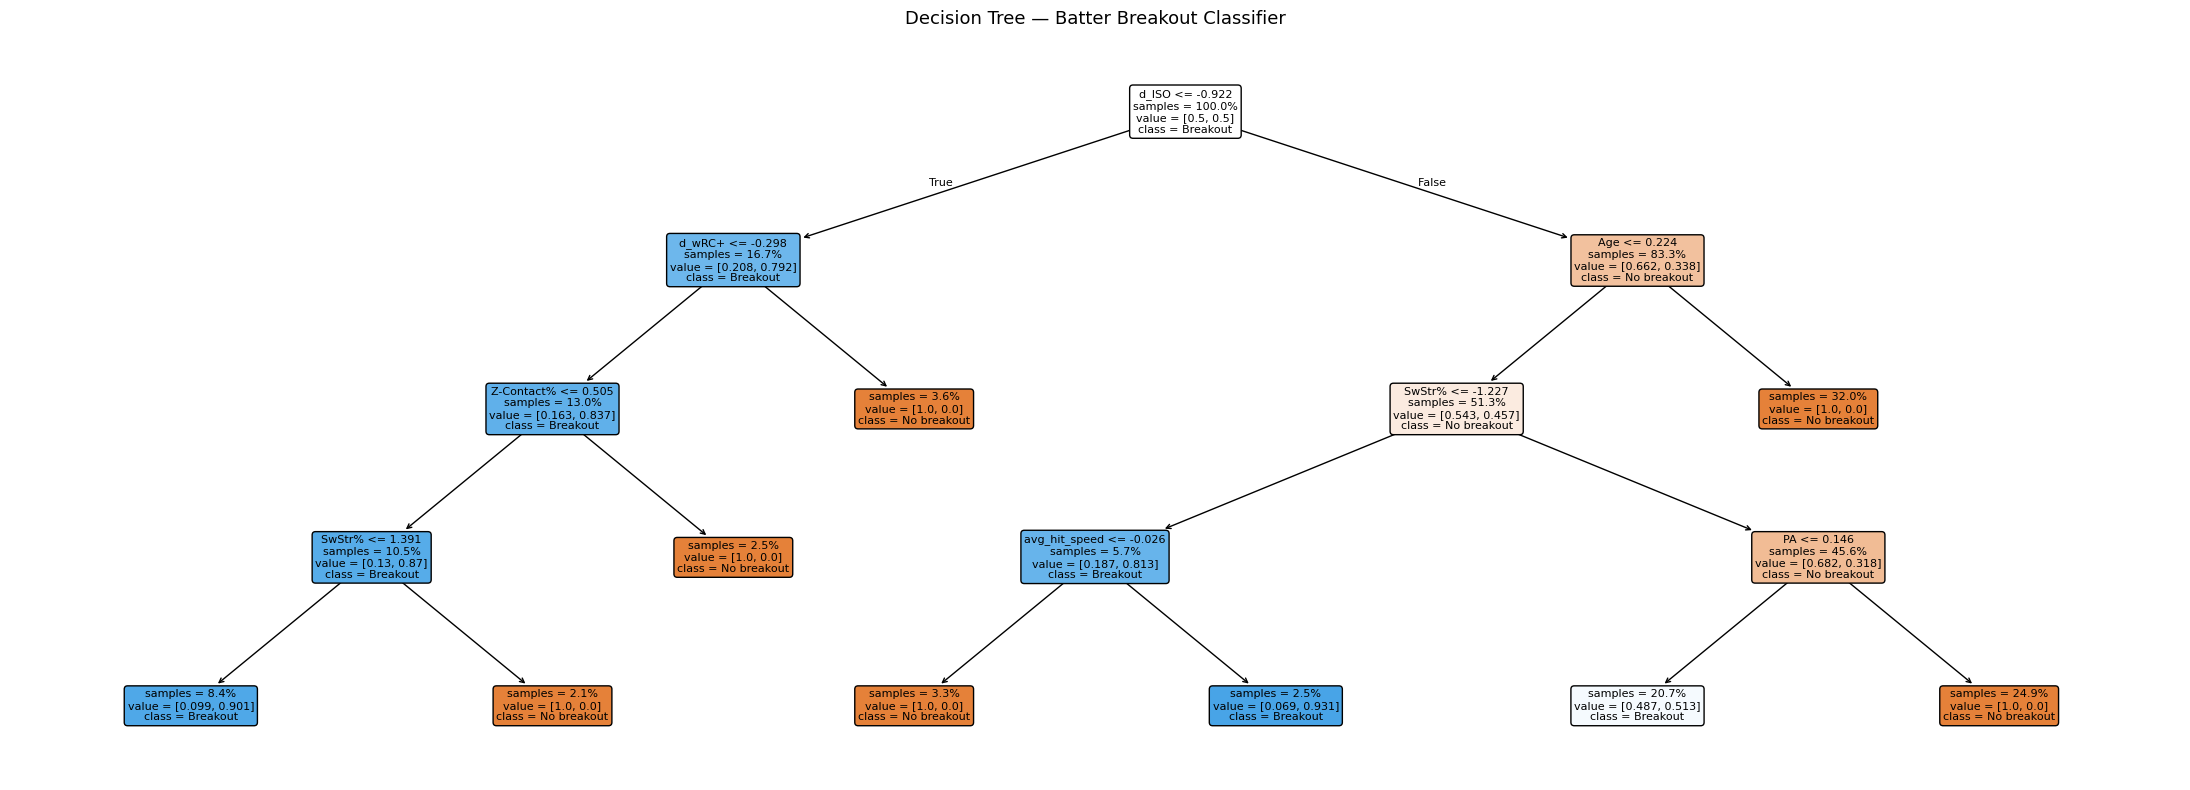

In [12]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    pipe_tree_bat.named_steps['tree'],
    feature_names=bat_feat_names,
    class_names=['No breakout', 'Breakout'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    impurity=False, proportion=True,
)
ax.set_title('Decision Tree — Batter Breakout Classifier', fontsize=13, pad=10)
plt.tight_layout()
plt.show()

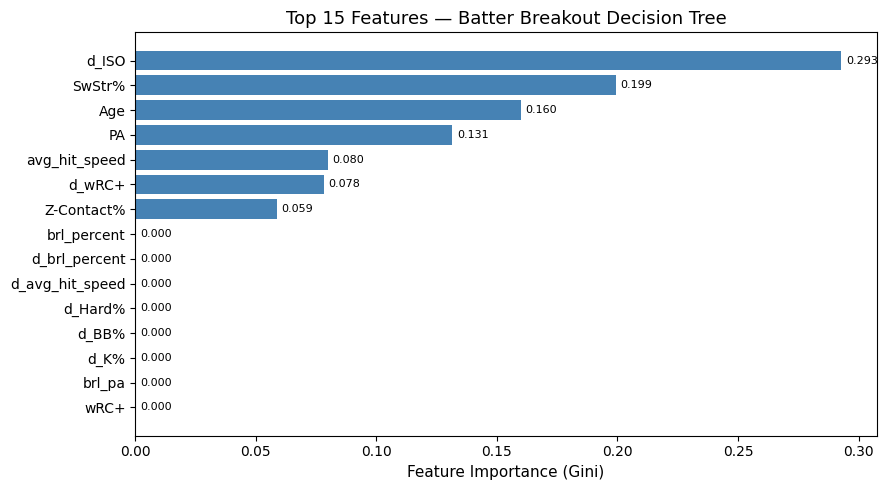

Top 15 batter breakout features:
d_ISO             0.29
SwStr%            0.20
Age               0.16
PA                0.13
avg_hit_speed     0.08
d_wRC+            0.08
Z-Contact%        0.06
brl_percent       0.00
d_brl_percent     0.00
d_avg_hit_speed   0.00
d_Hard%           0.00
d_BB%             0.00
d_K%              0.00
brl_pa            0.00
wRC+              0.00


In [13]:
importances_bat = pipe_tree_bat.named_steps['tree'].feature_importances_
feat_imp_bat = (
    pd.Series(importances_bat, index=bat_feat_names)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_imp_bat.index[::-1], feat_imp_bat.values[::-1], color='steelblue')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Top 15 Features — Batter Breakout Decision Tree', fontsize=13)
for bar, val in zip(bars, feat_imp_bat.values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 15 batter breakout features:')
print(feat_imp_bat.round(4).to_string())

## Section 6: Pitcher ML

Same pipeline as Section 5, applied to starting and relief pitchers. Spin rates are included where available.

In [14]:
trend_cols_pit_present = [c for c in PIT_TREND_FEAT if c in labeled_pit.columns]
pit_ml = labeled_pit.dropna(subset=trend_cols_pit_present[:2]).copy()

X_pit = pit_ml[PIT_FEATURES].copy()
y_pit = pit_ml['breakout'].values
pit_feat_names = list(X_pit.columns)  # ground truth feature names for model outputs

print(f'Pitcher ML matrix: {X_pit.shape}  |  breakouts: {y_pit.sum()} ({100*y_pit.mean():.1f}%)')

Pitcher ML matrix: (448, 27)  |  breakouts: 12 (2.7%)


In [15]:
pit_bo = pit_ml[pit_ml['breakout'] == 1].copy()
X_bo_pit = pit_bo[PIT_FEATURES]

pipe_cluster_pit = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('scaler',  StandardScaler()),
])
X_bo_pit_scaled = pipe_cluster_pit.fit_transform(X_bo_pit)

km_pit = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
pit_bo['cluster'] = km_pit.fit_predict(X_bo_pit_scaled)

pit_char_cols = [c for c in ['WAR', 'FIP', 'xFIP', 'ERA', 'K%', 'BB%', 'GB%', 'HR/FB',
                              'Age', 'IP', 'war_jump'] if c in pit_bo.columns]
pit_cluster_profile = pit_bo.groupby('cluster')[pit_char_cols].median().round(2)
pit_cluster_profile['n'] = pit_bo['cluster'].value_counts().sort_index()
print('Pitcher breakout cluster profiles (medians):')
print(pit_cluster_profile.to_string())

Pitcher breakout cluster profiles (medians):
          WAR  FIP  xFIP  ERA   K%  BB%  GB%  HR/FB   Age     IP  war_jump  n
cluster                                                                      
0        2.90 3.80  3.66 3.48 0.25 0.07 0.46   0.15 30.50 174.55      2.55  4
1        1.60 3.52  3.67 3.42 0.27 0.10 0.46   0.12 25.50  90.65      2.05  2
2        0.50 5.33  4.40 5.83 0.21 0.08 0.44   0.18 26.00 105.10      2.50  5
3       -0.90 5.62  4.07 5.19 0.27 0.13 0.44   0.24 31.00 100.20      3.50  1


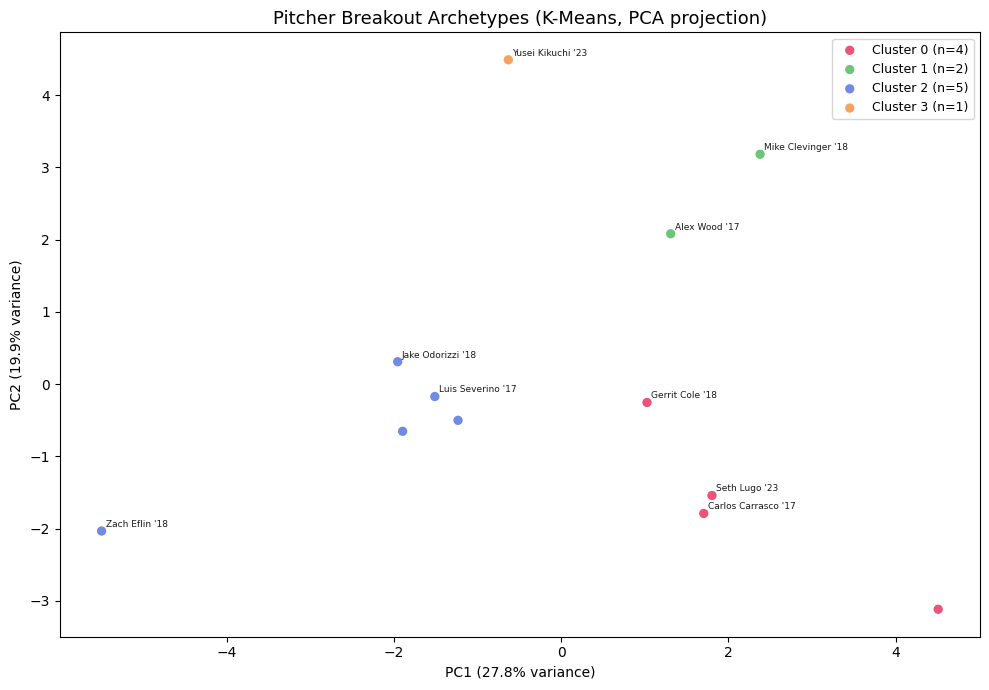

In [16]:
pca_pit = PCA(n_components=2, random_state=RANDOM_STATE)
coords_pit = pca_pit.fit_transform(X_bo_pit_scaled)
pit_bo['pca1'], pit_bo['pca2'] = coords_pit[:, 0], coords_pit[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(N_CLUSTERS):
    mask = pit_bo['cluster'] == c
    ax.scatter(pit_bo.loc[mask, 'pca1'], pit_bo.loc[mask, 'pca2'],
               c=CLUSTER_COLORS[c], label=f'Cluster {c} (n={mask.sum()})',
               alpha=0.75, s=45, edgecolors='none')
    top = pit_bo[mask].nlargest(3, 'war_jump')
    for _, row in top.iterrows():
        ax.annotate(f"{row['Name']} '{str(row['label_season'])[2:]}",
                    (row['pca1'], row['pca2']), fontsize=6.5, alpha=0.9,
                    xytext=(3, 3), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca_pit.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_pit.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Pitcher Breakout Archetypes (K-Means, PCA projection)', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [17]:
train_mask_pit = pit_ml['feature_season'] <= TRAIN_CUTOFF
X_train_pit, y_train_pit = X_pit[train_mask_pit], y_pit[train_mask_pit]

pipe_tree_pit = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('scaler',  StandardScaler()),
    ('tree', DecisionTreeClassifier(
        max_depth=TREE_DEPTH,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

cv_auc_pit = cross_val_score(pipe_tree_pit, X_train_pit, y_train_pit, cv=cv, scoring='roc_auc')
print(f'Pitcher tree CV ROC-AUC: {cv_auc_pit.mean():.3f} ± {cv_auc_pit.std():.3f}')

cv_f1_pit = cross_val_score(pipe_tree_pit, X_train_pit, y_train_pit, cv=cv, scoring='f1')
print(f'Pitcher tree CV F1:      {cv_f1_pit.mean():.3f} ± {cv_f1_pit.std():.3f}')

pipe_tree_pit.fit(X_train_pit, y_train_pit)

Pitcher tree CV ROC-AUC: 0.556 ± 0.157
Pitcher tree CV F1:      0.050 ± 0.069


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

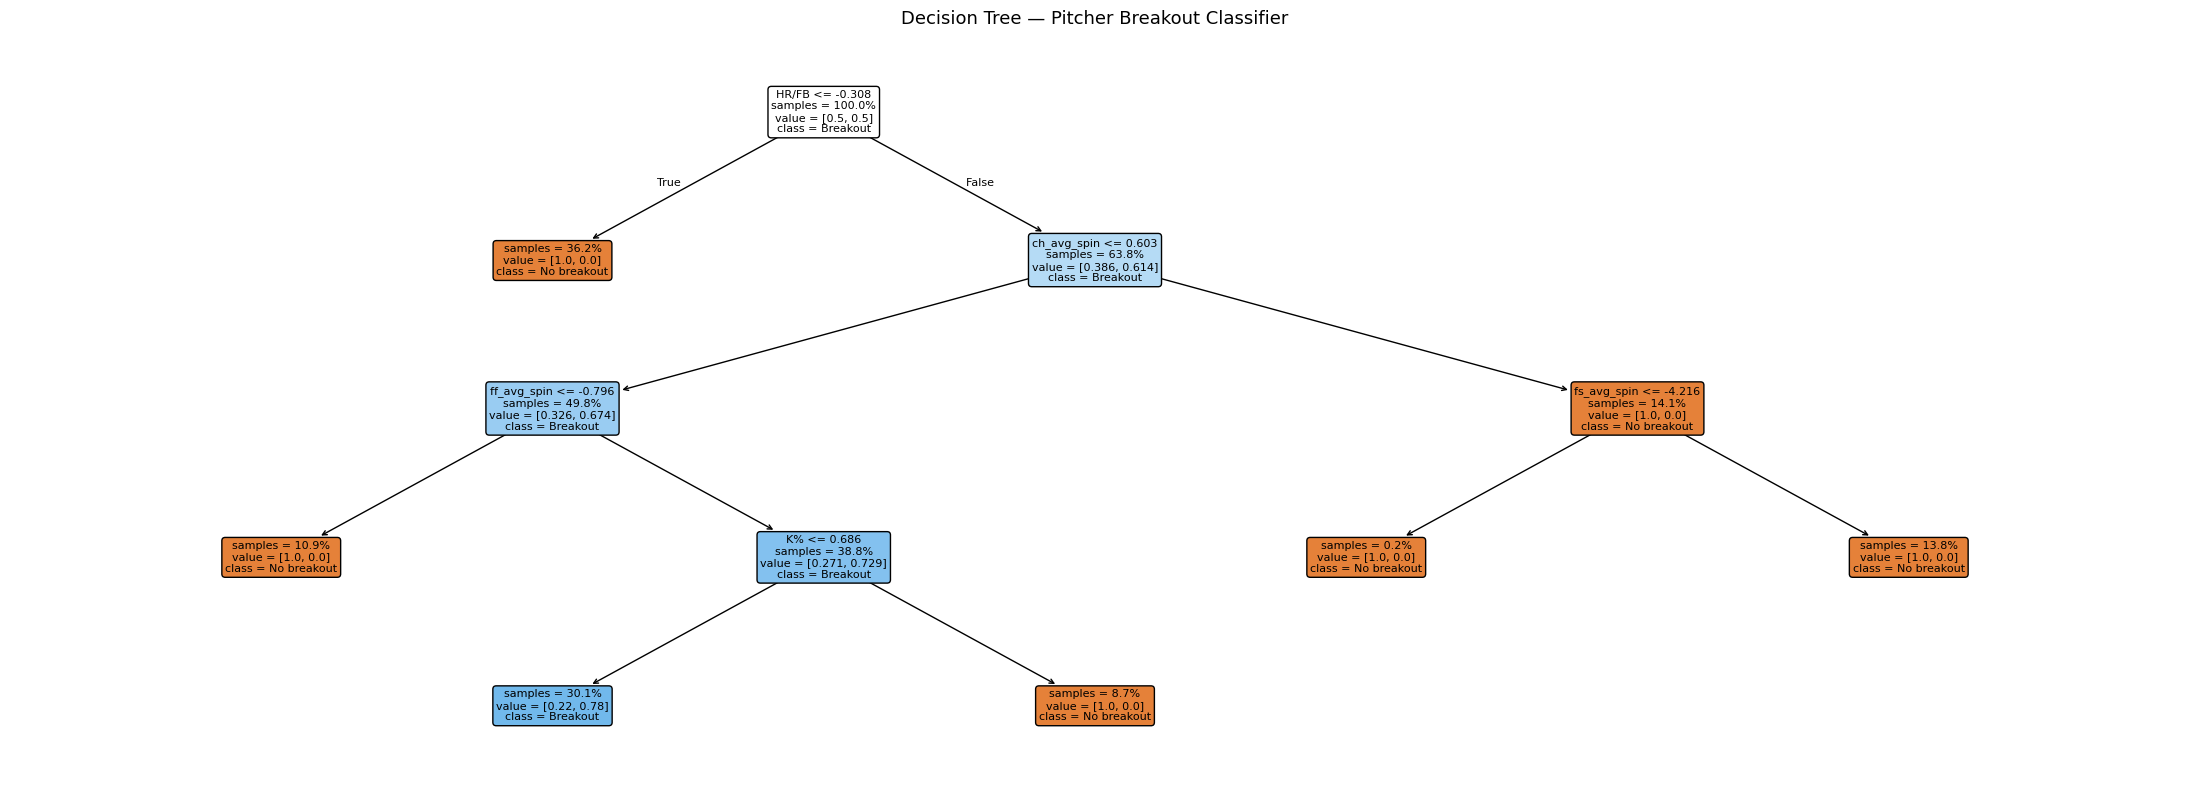

In [18]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    pipe_tree_pit.named_steps['tree'],
    feature_names=pit_feat_names,
    class_names=['No breakout', 'Breakout'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    impurity=False, proportion=True,
)
ax.set_title('Decision Tree — Pitcher Breakout Classifier', fontsize=13, pad=10)
plt.tight_layout()
plt.show()

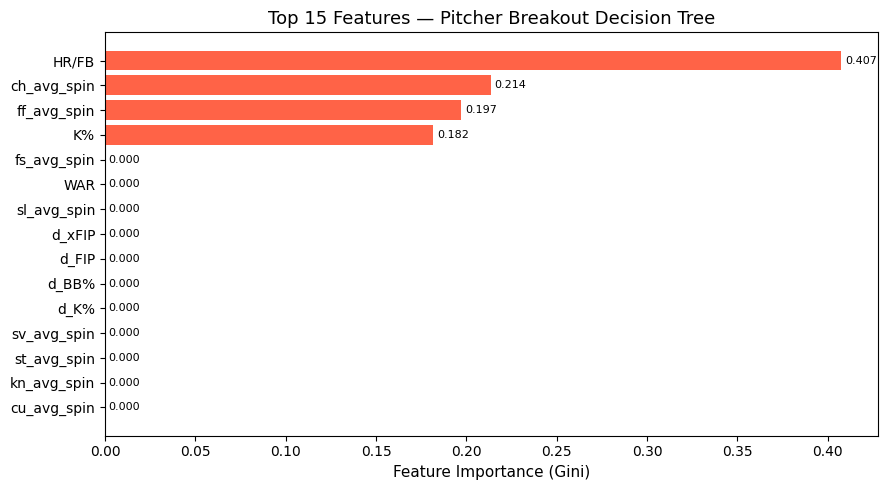

Top 15 pitcher breakout features:
HR/FB         0.41
ch_avg_spin   0.21
ff_avg_spin   0.20
K%            0.18
fs_avg_spin   0.00
WAR           0.00
sl_avg_spin   0.00
d_xFIP        0.00
d_FIP         0.00
d_BB%         0.00
d_K%          0.00
sv_avg_spin   0.00
st_avg_spin   0.00
kn_avg_spin   0.00
cu_avg_spin   0.00


In [19]:
importances_pit = pipe_tree_pit.named_steps['tree'].feature_importances_
feat_imp_pit = (
    pd.Series(importances_pit, index=pit_feat_names)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_imp_pit.index[::-1], feat_imp_pit.values[::-1], color='tomato')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Top 15 Features — Pitcher Breakout Decision Tree', fontsize=13)
for bar, val in zip(bars, feat_imp_pit.values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 15 pitcher breakout features:')
print(feat_imp_pit.round(4).to_string())

## Section 7: 2025 Breakout Predictions

Apply the trained pipelines to 2024 stats. Players meeting the minimum playing time threshold are scored, clustered, and ranked.

In [20]:
# ── 2025 batter candidates ────────────────────────────────────────────────────
bat_2024 = bat_all[bat_all['Season'] == PRED_SEASON].copy()
bat_2024['IDfg'] = bat_2024['IDfg'].astype(str)
bat_2024 = bat_2024[bat_2024['PA'] >= MIN_PA_FEAT].copy()

# Trend features: 2024 vs 2023
bat_2023 = bat_all[bat_all['Season'] == PRED_SEASON - 1].copy()
bat_2023['IDfg'] = bat_2023['IDfg'].astype(str)
trend_src = bat_2023[['IDfg'] + [c for c in BAT_TREND_COLS if c in bat_2023.columns]]
trend_src = trend_src.rename(columns={c: f'{c}_prev' for c in BAT_TREND_COLS})

bat_pred = bat_2024.merge(trend_src, on='IDfg', how='left')
for col in BAT_TREND_COLS:
    if col in bat_pred.columns and f'{col}_prev' in bat_pred.columns:
        bat_pred[f'd_{col}'] = bat_pred[col] - bat_pred[f'{col}_prev']
    else:
        bat_pred[f'd_{col}'] = np.nan

X_pred_bat = bat_pred[[c for c in bat_feat_names if c in bat_pred.columns]].reindex(columns=bat_feat_names)
bat_pred['breakout_prob'] = pipe_tree_bat.predict_proba(X_pred_bat)[:, 1]
bat_pred['breakout_pred'] = pipe_tree_bat.predict(X_pred_bat)

# Cluster assignment
X_pred_bat_scaled = pipe_cluster_bat.transform(X_pred_bat)
bat_pred['cluster'] = km_bat.predict(X_pred_bat_scaled)

print(f'Scored {len(bat_pred)} batters (≥{MIN_PA_FEAT} PA in {PRED_SEASON})')
print(f'Flagged as breakout candidates (prob > 20%): {(bat_pred["breakout_prob"] > 0.20).sum()}')

Scored 324 batters (≥250 PA in 2024)
Flagged as breakout candidates (prob > 20%): 146


In [21]:
bat_display_cols = ['Name', 'Team', 'Age', 'PA', 'WAR', 'wRC+', 'ISO',
                    'avg_hit_speed', 'brl_percent', 'breakout_prob', 'cluster']
bat_display_cols = [c for c in bat_display_cols if c in bat_pred.columns]

top_batters = (
    bat_pred[bat_pred['breakout_prob'] > 0.10]
    .sort_values('breakout_prob', ascending=False)
    [bat_display_cols]
    .reset_index(drop=True)
)
top_batters.index += 1
top_batters.index.name = 'rank'

print(f'Top 2025 Batter Breakout Candidates ({len(top_batters)} players):')
top_batters.head(30)

Top 2025 Batter Breakout Candidates (146 players):


,Name,Team,Age,PA,WAR,wRC+,ISO,avg_hit_speed,brl_percent,breakout_prob,cluster
rank,,,,,,,,,,,
1,Jonah Bride,MIA,28,272,1.10,124.00,0.18,NaN,NaN,0.93,2
2,Maikel Garcia,KCR,24,626,1.20,71.00,0.10,90.40,3.70,0.93,3
3,Willie Calhoun,LAA,29,254,0.00,97.00,0.14,NaN,NaN,0.93,3
4,Vinnie Pasquantino,KCR,26,554,1.50,109.00,0.18,91.00,7.10,0.93,2
5,Alejandro Kirk,TOR,25,386,2.80,93.00,0.11,89.40,6.70,0.93,2
6,Ha-seong Kim,SDP,28,470,2.60,101.00,0.14,NaN,NaN,0.93,2
7,Nick Fortes,MIA,27,335,0.60,58.00,0.09,NaN,NaN,0.93,3
8,Lars Nootbaar,STL,26,405,1.70,114.00,0.17,91.80,9.90,0.93,2
9,Brandon Drury,LAA,31,360,-2.10,35.00,0.06,87.60,3.60,0.90,3


In [22]:
# ── 2025 pitcher candidates ───────────────────────────────────────────────────
pit_2024 = pit_all[pit_all['Season'] == PRED_SEASON].copy()
pit_2024['IDfg'] = pit_2024['IDfg'].astype(str)
pit_2024 = pit_2024[pit_2024['IP'] >= MIN_IP_FEAT].copy()

pit_2023 = pit_all[pit_all['Season'] == PRED_SEASON - 1].copy()
pit_2023['IDfg'] = pit_2023['IDfg'].astype(str)
trend_src_pit = pit_2023[['IDfg'] + [c for c in PIT_TREND_COLS if c in pit_2023.columns]]
trend_src_pit = trend_src_pit.rename(columns={c: f'{c}_prev' for c in PIT_TREND_COLS})

pit_pred = pit_2024.merge(trend_src_pit, on='IDfg', how='left')
for col in PIT_TREND_COLS:
    if col in pit_pred.columns and f'{col}_prev' in pit_pred.columns:
        pit_pred[f'd_{col}'] = pit_pred[col] - pit_pred[f'{col}_prev']
    else:
        pit_pred[f'd_{col}'] = np.nan

X_pred_pit = pit_pred[[c for c in pit_feat_names if c in pit_pred.columns]].reindex(columns=pit_feat_names)
pit_pred['breakout_prob'] = pipe_tree_pit.predict_proba(X_pred_pit)[:, 1]
pit_pred['breakout_pred'] = pipe_tree_pit.predict(X_pred_pit)

X_pred_pit_scaled = pipe_cluster_pit.transform(X_pred_pit)
pit_pred['cluster'] = km_pit.predict(X_pred_pit_scaled)

print(f'Scored {len(pit_pred)} pitchers (≥{MIN_IP_FEAT} IP in {PRED_SEASON})')
print(f'Flagged as breakout candidates (prob > 20%): {(pit_pred["breakout_prob"] > 0.20).sum()}')

Scored 403 pitchers (≥40 IP in 2024)
Flagged as breakout candidates (prob > 20%): 97


In [23]:
pit_display_cols = ['Name', 'Team', 'role', 'Age', 'IP', 'WAR', 'FIP', 'xFIP',
                    'K%', 'BB%', 'breakout_prob', 'cluster']
pit_display_cols = [c for c in pit_display_cols if c in pit_pred.columns]

top_pitchers = (
    pit_pred[pit_pred['breakout_prob'] > 0.10]
    .sort_values('breakout_prob', ascending=False)
    [pit_display_cols]
    .reset_index(drop=True)
)
top_pitchers.index += 1
top_pitchers.index.name = 'rank'

print(f'Top 2025 Pitcher Breakout Candidates ({len(top_pitchers)} players):')
top_pitchers.head(30)

Top 2025 Pitcher Breakout Candidates (97 players):


,Name,Team,role,Age,IP,WAR,FIP,xFIP,K%,BB%,breakout_prob,cluster
rank,,,,,,,,,,,,
1,Max Fried,ATL,SP,30,174.10,3.40,3.33,3.33,0.23,0.08,0.78,0
2,Luis Garcia,- - -,RP,37,59.00,0.30,4.05,3.62,0.21,0.06,0.78,0
3,Keaton Winn,SFG,SP,26,55.10,0.00,4.85,4.07,0.20,0.08,0.78,2
4,Kenta Maeda,DET,SP,36,112.10,0.00,4.96,4.51,0.20,0.06,0.78,0
5,Carson Spiers,CIN,RP,26,90.20,0.00,5.33,4.65,0.20,0.07,0.78,2
6,Jose Urena,TEX,RP,32,109.00,0.00,4.62,4.61,0.15,0.08,0.78,1
7,Keider Montero,DET,SP,23,98.10,0.00,5.15,4.33,0.19,0.07,0.78,0
8,Jacob Barnes,WSN,RP,34,66.00,0.00,4.38,4.17,0.20,0.07,0.78,2
9,Hector Neris,- - -,RP,35,59.10,0.00,4.28,4.23,0.25,0.11,0.78,0


In [24]:
# ── Combined table ────────────────────────────────────────────────────────────
bat_summary = top_batters[['Name', 'Team', 'Age', 'WAR', 'breakout_prob', 'cluster']].copy()
bat_summary['type'] = 'batter'

pit_summary = top_pitchers[['Name', 'Team', 'Age', 'WAR', 'breakout_prob', 'cluster']].copy()
pit_summary['type'] = 'pitcher'

combined = (
    pd.concat([bat_summary, pit_summary], ignore_index=True)
    .sort_values('breakout_prob', ascending=False)
    .reset_index(drop=True)
)
combined.index += 1
combined.index.name = 'rank'

print(f'\n2025 Breakout Candidates — Top 40 (batters + pitchers):')
combined.head(40)


2025 Breakout Candidates — Top 40 (batters + pitchers):


,Name,Team,Age,WAR,breakout_prob,cluster,type
rank,,,,,,,
1,Jonah Bride,MIA,28,1.10,0.93,2,batter
2,Willie Calhoun,LAA,29,0.00,0.93,3,batter
3,Vinnie Pasquantino,KCR,26,1.50,0.93,2,batter
4,Alejandro Kirk,TOR,25,2.80,0.93,2,batter
5,Ha-seong Kim,SDP,28,2.60,0.93,2,batter
6,Nick Fortes,MIA,27,0.60,0.93,3,batter
7,Lars Nootbaar,STL,26,1.70,0.93,2,batter
8,Maikel Garcia,KCR,24,1.20,0.93,3,batter
9,Mitch Garver,SEA,33,-0.40,0.90,1,batter


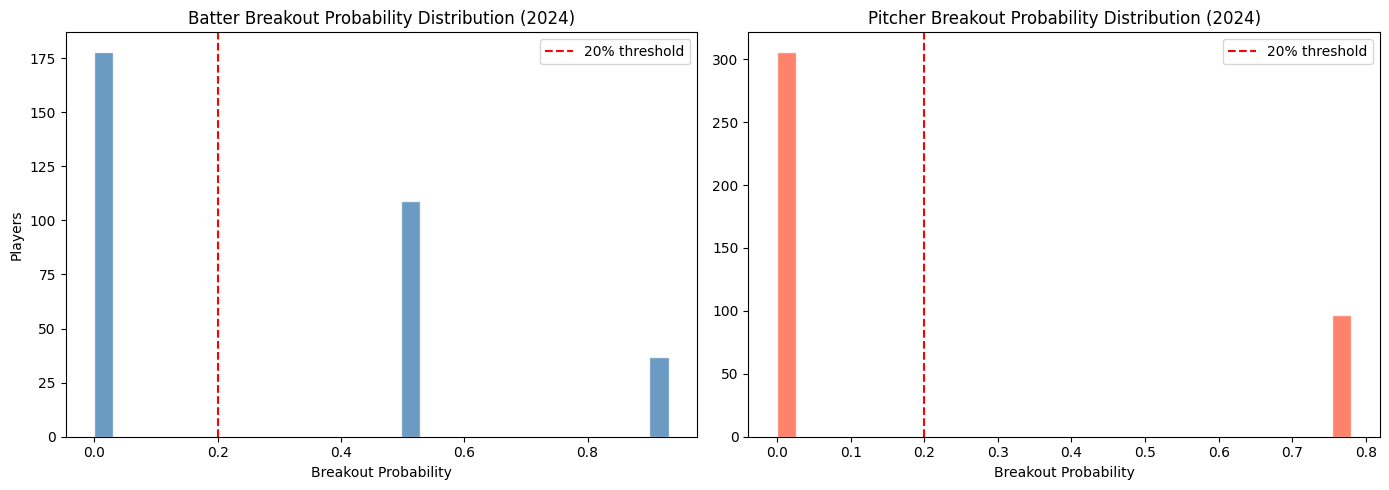

In [25]:
# ── Probability distribution chart ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(bat_pred['breakout_prob'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
ax1.axvline(0.20, color='red', linestyle='--', label='20% threshold')
ax1.set_xlabel('Breakout Probability')
ax1.set_ylabel('Players')
ax1.set_title(f'Batter Breakout Probability Distribution ({PRED_SEASON})', fontsize=12)
ax1.legend()

ax2.hist(pit_pred['breakout_prob'], bins=30, color='tomato', alpha=0.8, edgecolor='white')
ax2.axvline(0.20, color='red', linestyle='--', label='20% threshold')
ax2.set_xlabel('Breakout Probability')
ax2.set_title(f'Pitcher Breakout Probability Distribution ({PRED_SEASON})', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

## Section 8: Verification

Sanity checks, known-breakout spot-checks, and a held-out validation on the 2021→2022 window.

In [26]:
# ── 1. No data leakage ────────────────────────────────────────────────────────
assert 'war_n'  not in X_bat.columns, 'Leakage: war_n in batter features'
assert 'war_n'  not in X_pit.columns, 'Leakage: war_n in pitcher features'
assert 'war_n1' not in X_bat.columns, 'Leakage: war_n1 in batter features'
print('✓ No data leakage')

# ── 2. Breakout rates are sensible ────────────────────────────────────────────
bat_rate = labeled_bat['breakout'].mean()
pit_rate = labeled_pit['breakout'].mean()
assert 0.03 < bat_rate < 0.25, f'Unexpected batter breakout rate: {bat_rate:.3f}'
assert 0.03 < pit_rate < 0.25, f'Unexpected pitcher breakout rate: {pit_rate:.3f}'
print(f'✓ Breakout rates — batters: {bat_rate:.1%}  pitchers: {pit_rate:.1%}')

# ── 3. Predictions are valid probabilities ────────────────────────────────────
assert bat_pred['breakout_prob'].between(0, 1).all()
assert pit_pred['breakout_prob'].between(0, 1).all()
print(f'✓ Probabilities in [0,1]')

# ── 4. Sufficient candidate pool ─────────────────────────────────────────────
assert len(bat_pred) >= 200, f'Too few batters scored: {len(bat_pred)}'
assert len(pit_pred) >= 100, f'Too few pitchers scored: {len(pit_pred)}'
print(f'✓ Pool size — batters: {len(bat_pred)}  pitchers: {len(pit_pred)}')

# ── 5. Cluster counts match config ───────────────────────────────────────────
assert km_bat.n_clusters == N_CLUSTERS
assert km_pit.n_clusters == N_CLUSTERS
print(f'✓ K-Means clusters: {N_CLUSTERS}')

print('\nAll assertions passed.')

✓ No data leakage
✓ Breakout rates — batters: 5.3%  pitchers: 3.3%
✓ Probabilities in [0,1]
✓ Pool size — batters: 324  pitchers: 403
✓ K-Means clusters: 4

All assertions passed.


In [27]:
# ── 6. Spot-check known historical breakouts ──────────────────────────────────
# These players had well-documented breakout seasons
known_breakouts = [
    ('Jose Ramirez',   2017),  # ~3.5 WAR jump
    ('Ronald Acuña Jr.', 2019),
    ('Freddie Freeman',  2020),
]

print('Known breakout spot-checks:')
for name, bo_year in known_breakouts:
    feat_yr = bo_year - 1
    rows = labeled_bat[
        labeled_bat['Name'].str.contains(name.split()[0], case=False, na=False) &
        labeled_bat['Name'].str.contains(name.split()[-1], case=False, na=False) &
        (labeled_bat['label_season'] == bo_year)
    ]
    if rows.empty:
        print(f'  {name} {bo_year}: NOT IN DATASET (may not meet PA threshold or outside 2015-2024)')
    else:
        r = rows.iloc[0]
        label = int(r['breakout'])
        status = '✓ correctly labeled breakout' if label == 1 else '✗ missed (check WAR jump or sustain)'
        print(f'  {name} {bo_year}: WAR {r["war_n1"]:.1f}→{r["war_n"]:.1f} (jump={r["war_jump"]:.1f}, '
              f'sustained={r["war_n_plus1"]:.1f}) → label={label} {status}')

Known breakout spot-checks:
  Jose Ramirez 2017: WAR 5.0→7.0 (jump=2.0, sustained=7.6) → label=1 ✓ correctly labeled breakout
  Ronald Acuña Jr. 2019: NOT IN DATASET (may not meet PA threshold or outside 2015-2024)
  Freddie Freeman 2020: NOT IN DATASET (may not meet PA threshold or outside 2015-2024)


In [28]:
# ── 7. Holdout validation: train on 2015-2020, predict 2021→2022 ──────────────
holdout_mask_bat = bat_ml['feature_season'] == 2021
X_holdout_bat    = X_bat[holdout_mask_bat]
y_holdout_bat    = y_bat[holdout_mask_bat]

# Retrain on ≤2020
train_2020 = bat_ml['feature_season'] <= 2020
pipe_holdout = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('tree', DecisionTreeClassifier(
        max_depth=TREE_DEPTH, class_weight='balanced', random_state=RANDOM_STATE,
    )),
])
pipe_holdout.fit(X_bat[train_2020], y_bat[train_2020])
probs_holdout = pipe_holdout.predict_proba(X_holdout_bat)[:, 1]

holdout_df = bat_ml[holdout_mask_bat][['Name', 'war_n1', 'war_n', 'war_jump', 'breakout']].copy()
holdout_df['pred_prob'] = probs_holdout

top_holdout = holdout_df.sort_values('pred_prob', ascending=False).head(25)
true_pos_in_top25 = top_holdout['breakout'].sum()

print(f'Holdout (2022 breakouts identified from 2021 features):')
print(f'  True breakouts in top 25 predictions: {true_pos_in_top25}')
print(f'  Actual breakouts in 2021 feature cohort: {y_holdout_bat.sum()}')
print()
print('Top 25 predicted breakouts for 2022 (features from 2021):')
print(top_holdout[['Name', 'breakout', 'pred_prob', 'war_n1', 'war_n', 'war_jump']].to_string(index=False))

Holdout (2022 breakouts identified from 2021 features):
  True breakouts in top 25 predictions: 3
  Actual breakouts in 2021 feature cohort: 7

Top 25 predicted breakouts for 2022 (features from 2021):
             Name  breakout  pred_prob  war_n1  war_n  war_jump
   Randal Grichuk         0       0.97    0.60   0.50     -0.10
  Jonathan Schoop         0       0.97    2.20   1.30     -0.90
  Whit Merrifield         0       0.97    2.60   1.30     -1.30
   Miguel Cabrera         0       0.97   -0.50  -1.30     -0.80
 Francisco Lindor         1       0.97    3.90   6.40      2.50
 Charlie Blackmon         0       0.97   -0.10   0.20      0.30
       Max Kepler         0       0.74    2.20   1.60     -0.60
Andrew Benintendi         0       0.74    1.40   2.00      0.60
   Dansby Swanson         0       0.74    3.30   6.60      3.30
     Tim Anderson         0       0.74    4.30   2.20     -2.10
    Manuel Margot         0       0.74    2.10   1.30     -0.80
  Xander Bogaerts         0   